# 3c. Experiments — Dogfight (MAFixedwingDogfightEnvV2)

This notebook trains and compares three policies on the self-play dogfight environment:

| Agent | Type | Library |
|---|---|---|
| **Random** | Baseline | — |
| **SAC** | Off-policy, entropy-regularised | Custom PyTorch |
| **PPO** | On-policy, clipped surrogate | Stable-Baselines3 |

**Key differences from Hover and Waypoints:**
- Multi-agent PettingZoo environment wrapped into a single-agent Gymnasium env by `DogfightSelfPlayEnv`
- Action space is **already** in `[-1, 1]^4` — no rescaling needed
- Reward is extremely **sparse**: most steps yield 0, large positive/negative spikes only on hit/destruction
- Transition is **stochastic** from the agent's perspective: the opponent's policy changes as training progresses (self-play)
- Observation is a flat `ndarray(37,)` — no flattening wrapper needed

**Tournament note:** the trained PPO is directly usable as a tournament submission via `predict(obs, deterministic=True)`.

## 0. Imports & config

In [1]:
import numpy as np
import gymnasium as gym
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from scripts.dogfight_wrapper import DogfightSelfPlayEnv
from algorithms import SACAgent, PPOAgent

# ── reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── obs / action dims ─────────────────────────────────────────
_env_tmp   = DogfightSelfPlayEnv()
STATE_DIM  = _env_tmp.observation_space.shape[0]   # 37
ACTION_DIM = _env_tmp.action_space.shape[0]         # 4
ACTION_LOW  = _env_tmp.action_space.low              # [-1,-1,-1,-1]
ACTION_HIGH = _env_tmp.action_space.high             # [ 1, 1, 1, 1]
_env_tmp.close()

# ── eval config ──────────────────────────────────────────────
MAX_STEPS  = 1800   # 60 s × 30 Hz
EVAL_EPS   = 10

print(f"State dim  : {STATE_DIM}")
print(f"Action dim : {ACTION_DIM}  bounds [{ACTION_LOW[0]}, {ACTION_HIGH[0]}]")
print(f"Device     : {'cuda' if torch.cuda.is_available() else 'cpu'}")

State dim  : 37
Action dim : 4  bounds [-1.0, 1.0]
Device     : cuda


## 1. Evaluation helper

The dogfight wrapper does not accept a `seed` argument in `reset()` (the opponent position is randomised internally). We therefore evaluate without fixed seeds — the variance across episodes reflects the stochasticity of the opponent and the initial conditions.

In [2]:
def make_env():
    return DogfightSelfPlayEnv()


def eval_agent(policy_fn, label, n_episodes=EVAL_EPS, max_steps=MAX_STEPS):
    """
    Evaluate policy_fn over n_episodes.
    Returns (mean, std, list_of_returns).
    """
    env = make_env()
    returns = []

    for _ in tqdm(range(n_episodes), desc=f"Eval [{label}]"):
        obs, _ = env.reset()
        total  = 0.0
        for _ in range(max_steps):
            action = policy_fn(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            total += reward
            if terminated or truncated:
                break
        returns.append(total)

    env.close()
    mean, std = float(np.mean(returns)), float(np.std(returns))
    print(f"  {label:<14}  mean={mean:8.2f}  std={std:7.2f}")
    return mean, std, returns

## 2. Random baseline

In [3]:
_env_tmp = make_env()
_action_space = _env_tmp.action_space
_env_tmp.close()

rand_mean, rand_std, rand_returns = eval_agent(
    lambda obs: _action_space.sample(), "Random"
)

Eval [Random]:   0%|          | 0/10 [00:00<?, ?it/s]

Eval [Random]:  10%|█         | 1/10 [00:18<02:42, 18.06s/it]

Eval [Random]:  20%|██        | 2/10 [00:18<01:02,  7.77s/it]

Eval [Random]:  30%|███       | 3/10 [00:19<00:33,  4.72s/it]

Eval [Random]:  40%|████      | 4/10 [00:23<00:25,  4.32s/it]

...

Eval [Random]:  70%|███████   | 7/10 [00:29<00:07,  2.39s/it]

Eval [Random]:  80%|████████  | 8/10 [00:30<00:04,  2.00s/it]

Eval [Random]:  90%|█████████ | 9/10 [00:31<00:01,  1.72s/it]

Eval [Random]: 100%|██████████| 10/10 [00:33<00:00,  3.31s/it]

  Random          mean= 1351.13  std=1555.04


## 3. SAC — Soft Actor-Critic

### 3.1 What changes vs Hover

- **Action space is already `[-1,1]^4`**: `_scale_action` maps from (-1,1) to [-1,1] which is the identity — action scaling is a no-op but causes no harm.
- **Extremely sparse reward**: the replay buffer will be almost entirely zero-reward transitions for the first many episodes. Reward normalisation is especially important here: without it, the critic would correctly learn Q≈0 everywhere and the actor gradient would vanish.
- **Non-stationary opponent**: the dogfight wrapper replays the agent's own past actions as the opponent during self-play. This makes the effective MDP non-stationary, which hurts off-policy methods more than on-policy ones — the Q-function trained against an old opponent may be inaccurate once the policy improves. This is a known limitation of SAC in self-play settings.

### 3.2 Hyperparameters

In [4]:
SAC_EPISODES   = 500
SAC_MAX_STEPS  = 1800
SAC_BATCH_SIZE = 256
SAC_GAMMA      = 0.99
SAC_TAU        = 0.005
SAC_ALPHA      = 0.1    # lower than Hover: sparse reward means high entropy
                        # is less useful — we want the policy to commit faster
SAC_LR         = 3e-4
SAC_BUFFER     = 500_000

### 3.3 Training loop

In [5]:
env_sac = make_env()

sac = SACAgent(
    state_dim        = STATE_DIM,
    action_dim       = ACTION_DIM,
    action_low       = ACTION_LOW,
    action_high      = ACTION_HIGH,
    gamma            = SAC_GAMMA,
    tau              = SAC_TAU,
    alpha            = SAC_ALPHA,
    lr               = SAC_LR,
    buffer_size      = SAC_BUFFER,
    normalize_rewards= True,
)

sac_train_returns = []

for ep in tqdm(range(SAC_EPISODES), desc="Training SAC"):
    obs, _ = env_sac.reset()
    ep_reward = 0.0

    for _ in range(SAC_MAX_STEPS):
        # Dogfight action space is [-1,1]^4 — env_action is effectively act()
        a_norm = sac.act(obs, deterministic=False)
        a_env  = sac.env_action(obs, deterministic=False)

        next_obs, reward, terminated, truncated, _ = env_sac.step(a_env)
        done = terminated or truncated

        sac.store(obs, a_norm, reward, next_obs, float(done))
        sac.update(batch_size=SAC_BATCH_SIZE)

        obs        = next_obs
        ep_reward += reward
        if done:
            break

    sac_train_returns.append(ep_reward)

env_sac.close()
print(f"\nSAC training done. Last-20 mean: {np.mean(sac_train_returns[-20:]):.2f}")

Training SAC:   0%|          | 0/500 [00:00<?, ?it/s]

Training SAC:   0%|          | 1/500 [00:00<06:53,  1.21it/s]

Training SAC:   0%|          | 2/500 [00:01<06:37,  1.25it/s]

Training SAC:   1%|          | 3/500 [00:02<06:58,  1.19it/s]

Training SAC:   1%|          | 4/500 [00:03<08:49,  1.07s/it]

...

Training SAC:  99%|█████████▉| 497/500 [43:54<00:23,  7.82s/it]

Training SAC: 100%|█████████▉| 498/500 [44:01<00:15,  7.68s/it]

Training SAC: 100%|█████████▉| 499/500 [44:03<00:05,  5.97s/it]

Training SAC: 100%|██████████| 500/500 [44:08<00:00,  5.30s/it]


SAC training done. Last-20 mean: 1283.04


### 3.4 Evaluate SAC

In [6]:
sac_mean, sac_std, sac_returns = eval_agent(
    lambda obs: sac.predict(obs, deterministic=True)[0], "SAC"
)

Eval [SAC]:   0%|          | 0/10 [00:00<?, ?it/s]

Eval [SAC]:  10%|█         | 1/10 [00:02<00:22,  2.54s/it]

Eval [SAC]:  20%|██        | 2/10 [00:03<00:10,  1.34s/it]

Eval [SAC]:  30%|███       | 3/10 [00:05<00:11,  1.69s/it]

Eval [SAC]:  40%|████      | 4/10 [00:07<00:11,  1.86s/it]

...

Eval [SAC]:  70%|███████   | 7/10 [00:14<00:06,  2.20s/it]

Eval [SAC]:  80%|████████  | 8/10 [00:18<00:05,  2.54s/it]

Eval [SAC]:  90%|█████████ | 9/10 [00:20<00:02,  2.61s/it]

Eval [SAC]: 100%|██████████| 10/10 [00:22<00:00,  2.27s/it]

  SAC             mean= 1360.40  std=1210.43


### 3.5 Training curve — SAC

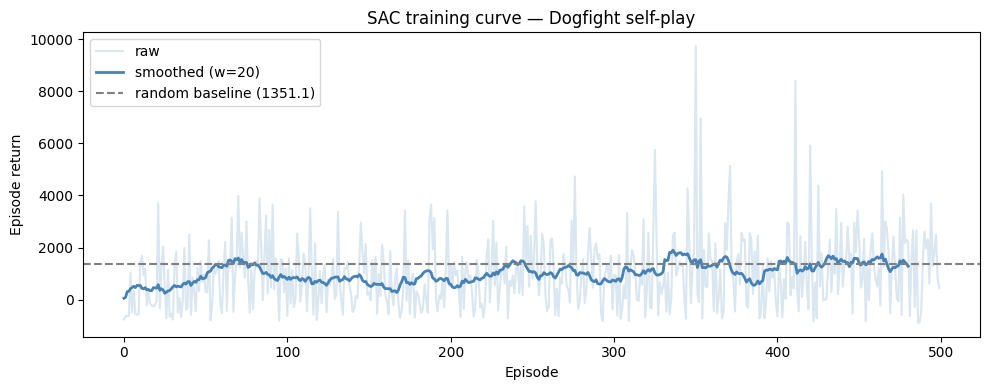

In [7]:
def smooth(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sac_train_returns, alpha=0.2, color='steelblue', label='raw')
ax.plot(range(len(smooth(sac_train_returns))), smooth(sac_train_returns),
        color='steelblue', lw=2, label='smoothed (w=20)')
ax.axhline(rand_mean, color='grey', linestyle='--',
           label=f'random baseline ({rand_mean:.1f})')
ax.set_xlabel('Episode')
ax.set_ylabel('Episode return')
ax.set_title('SAC training curve — Dogfight self-play')
ax.legend()
plt.tight_layout()
plt.show()

## 4. PPO — Proximal Policy Optimisation

### 4.1 Why PPO is better suited for dogfight

Self-play creates a non-stationary MDP: as the policy improves, the opponent it faces also changes. PPO's on-policy updates always use data collected against the *current* opponent, so the value function and policy are always consistent with the latest self. SAC's replay buffer contains transitions against older, weaker opponents — this off-policy mismatch can cause the Q-function to overestimate returns against the current (stronger) opponent.

PPO is also robust to reward sparsity through GAE: a reward signal received 500 steps after an action still propagates through the advantage estimate, whereas SAC's 1-step TD target discounts it geometrically.

### 4.2 Hyperparameters

In [8]:
PPO_TIMESTEPS = 1_000_000  # dogfight needs more steps — sparse reward + long episodes
PPO_N_STEPS   = 4096       # longer rollouts to capture full combat episodes
PPO_BATCH     = 128
PPO_EPOCHS    = 10
PPO_GAMMA     = 0.99
PPO_GAE       = 0.95
PPO_CLIP      = 0.2
PPO_LR        = 3e-4
PPO_ENT_COEF  = 0.01       # small entropy bonus to keep exploration alive
                            # in a sparse-reward environment

### 4.3 Training

In [9]:
env_ppo = make_env()

ppo = PPOAgent(
    env          = env_ppo,
    learning_rate= PPO_LR,
    n_steps      = PPO_N_STEPS,
    batch_size   = PPO_BATCH,
    n_epochs     = PPO_EPOCHS,
    gamma        = PPO_GAMMA,
    gae_lambda   = PPO_GAE,
    clip_range   = PPO_CLIP,
    ent_coef     = PPO_ENT_COEF,
    verbose      = 1,
    seed         = SEED,
)

ppo.train(total_timesteps=PPO_TIMESTEPS)
env_ppo.close()

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
                             


f:\Dev\anaconda\envs\rl\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


                                                                                                                                                                                                                                                                                                                                                                                                                                                   
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 257      |
|    ep_rew_mean     | 1.24e+03 |
| time/              |          |
|    fps             | 98       |
|    iterations      | 1        |
|    time_elapsed    | 41       |
|    total_timesteps | 4096     |
---------------------------------                                                                                                                                                                                                                                 

### 4.4 Evaluate PPO

In [10]:
ppo_mean, ppo_std, ppo_returns = eval_agent(
    lambda obs: ppo.predict(obs, deterministic=True)[0], "PPO"
)

Eval [PPO]:   0%|          | 0/10 [00:00<?, ?it/s]

Eval [PPO]:  10%|█         | 1/10 [00:01<00:17,  1.97s/it]

Eval [PPO]:  20%|██        | 2/10 [00:04<00:19,  2.41s/it]

Eval [PPO]:  30%|███       | 3/10 [00:10<00:27,  3.92s/it]

Eval [PPO]:  40%|████      | 4/10 [00:11<00:16,  2.78s/it]

...

Eval [PPO]:  70%|███████   | 7/10 [00:23<00:12,  4.04s/it]

Eval [PPO]:  80%|████████  | 8/10 [00:29<00:09,  4.77s/it]

Eval [PPO]:  90%|█████████ | 9/10 [00:43<00:07,  7.44s/it]

Eval [PPO]: 100%|██████████| 10/10 [00:45<00:00,  4.58s/it]

  PPO             mean= 6261.40  std=4628.94


## 5. Results summary

### 5.1 Numerical table

In [11]:
print(f"{'Agent':<14} {'Mean return':>14} {'Std':>10} {'95% CI':>22}")
print("-" * 64)
for label, mean, std, rets in [
    ("Random", rand_mean, rand_std, rand_returns),
    ("SAC",    sac_mean,  sac_std,  sac_returns),
    ("PPO",    ppo_mean,  ppo_std,  ppo_returns),
]:
    n     = len(rets)
    se    = std / np.sqrt(n)
    ci_lo = mean - 1.96 * se
    ci_hi = mean + 1.96 * se
    print(f"{label:<14} {mean:>14.2f} {std:>10.2f}  [{ci_lo:9.2f}, {ci_hi:9.2f}]")

Agent             Mean return        Std                 95% CI
----------------------------------------------------------------
Random                1351.13    1555.04  [   387.30,   2314.95]
SAC                   1360.40    1210.43  [   610.17,   2110.63]
PPO                   6261.40    4628.94  [  3392.35,   9130.44]


### 5.2 Bar chart with error bars

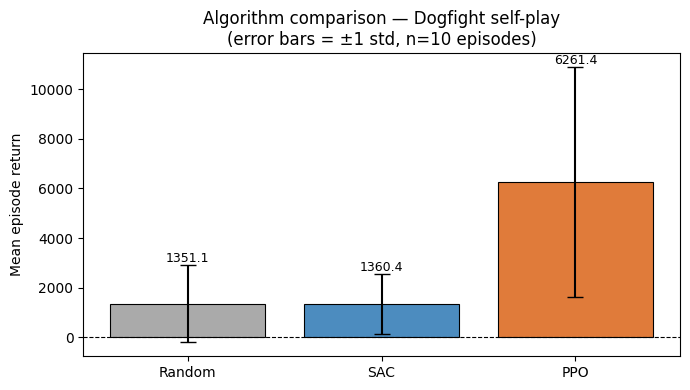

In [12]:
labels = ["Random", "SAC", "PPO"]
means  = [rand_mean, sac_mean, ppo_mean]
stds   = [rand_std,  sac_std,  ppo_std]
colors = ["#aaaaaa", "#4c8cbf", "#e07b3a"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, means, yerr=stds, capsize=6,
              color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Mean episode return')
ax.set_title(
    f'Algorithm comparison — Dogfight self-play\n'
    f'(error bars = ±1 std, n={EVAL_EPS} episodes)'
)
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            mean + std + 0.5, f'{mean:.1f}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 5.3 Return distribution (box plot)

C:\Users\Megaport\AppData\Local\Temp\ipykernel_17604\631986744.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


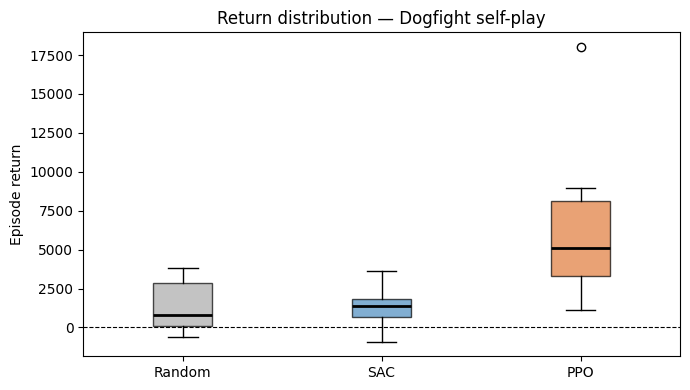

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
bp = ax.boxplot(
    [rand_returns, sac_returns, ppo_returns],
    labels=labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Episode return')
ax.set_title('Return distribution — Dogfight self-play')
plt.tight_layout()
plt.show()

### 5.4 SAC training curve vs baselines

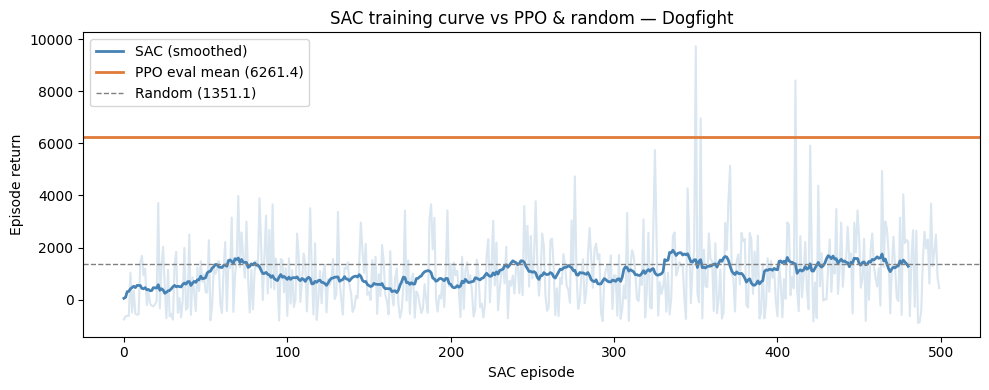

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sac_train_returns, alpha=0.2, color='steelblue')
ax.plot(smooth(sac_train_returns), color='steelblue', lw=2, label='SAC (smoothed)')
ax.axhline(ppo_mean,  color='#e07b3a', lw=2, label=f'PPO eval mean ({ppo_mean:.1f})')
ax.axhline(rand_mean, color='grey', linestyle='--', lw=1, label=f'Random ({rand_mean:.1f})')
ax.set_xlabel('SAC episode')
ax.set_ylabel('Episode return')
ax.set_title('SAC training curve vs PPO & random — Dogfight')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Save models

In [15]:
import os
os.makedirs("checkpoints", exist_ok=True)

torch.save({
    'actor': sac.actor.state_dict(),
    'q1':    sac.q1.state_dict(),
    'q2':    sac.q2.state_dict(),
    'q1_t':  sac.q1_t.state_dict(),
    'q2_t':  sac.q2_t.state_dict(),
    'reward_norm_mean':  sac._reward_norm.mean,
    'reward_norm_var':   sac._reward_norm.var,
    'reward_norm_count': sac._reward_norm.count,
}, "checkpoints/sac_dogfight.pt")

ppo.save("checkpoints/ppo_dogfight")
print("Saved to ./checkpoints/")

Saved to ./checkpoints/


## 7. Tournament submission — PPO

Copy the block below into `groupXX_name.py` and adjust the checkpoint path.
The `predict(obs, deterministic=True)` interface is already satisfied by `PPOAgent`.

In [16]:
# ── tournament submission template ───────────────────────────
# Copy this into groupXX_ppo_dogfight.py

SUBMISSION_CODE = '''
from stable_baselines3 import PPO

_model = None

def load_model():
    global _model
    _model = PPO.load("checkpoints/ppo_dogfight")
    return _model
'''

print(SUBMISSION_CODE)

# Quick sanity check — reload and run one episode
from stable_baselines3 import PPO as SB3PPO
model_check = SB3PPO.load("checkpoints/ppo_dogfight")

env_check = make_env()
obs, _ = env_check.reset()
total  = 0.0
for _ in range(MAX_STEPS):
    action, _ = model_check.predict(obs, deterministic=True)
    obs, r, term, trunc, _ = env_check.step(action)
    total += r
    if term or trunc:
        break
env_check.close()
print(f"Tournament sanity check — episode return: {total:.2f}")


from stable_baselines3 import PPO

_model = None

def load_model():
    global _model
    _model = PPO.load("checkpoints/ppo_dogfight")
    return _model



f:\Dev\anaconda\envs\rl\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


                             
Tournament sanity check — episode return: 7809.61


## 8. Reload & verify

In [ ]:
# ── reload SAC ───────────────────────────────────────────────
sac_loaded = SACAgent(
    state_dim   = STATE_DIM,
    action_dim  = ACTION_DIM,
    action_low  = ACTION_LOW,
    action_high = ACTION_HIGH,
)
ckpt = torch.load("checkpoints/sac_dogfight.pt", map_location='cpu', weights_only=False)
sac_loaded.actor.load_state_dict(ckpt['actor'])
sac_loaded.q1.load_state_dict(ckpt['q1'])
sac_loaded.q2.load_state_dict(ckpt['q2'])
sac_loaded._reward_norm.mean  = ckpt['reward_norm_mean']
sac_loaded._reward_norm.var   = ckpt['reward_norm_var']
sac_loaded._reward_norm.count = ckpt['reward_norm_count']

sac_rl_mean, _, _ = eval_agent(
    lambda obs: sac_loaded.predict(obs, deterministic=True)[0], "SAC (reloaded)"
)

# ── reload PPO ───────────────────────────────────────────────
env_reload = make_env()
ppo_loaded = PPOAgent.load("checkpoints/ppo_dogfight", env=env_reload)
ppo_rl_mean, _, _ = eval_agent(
    lambda obs: ppo_loaded.predict(obs, deterministic=True)[0], "PPO (reloaded)"
)
env_reload.close()

print(f"\nSanity check:")
print(f"  SAC  original={sac_mean:.2f}  reloaded={sac_rl_mean:.2f}")
print(f"  PPO  original={ppo_mean:.2f}  reloaded={ppo_rl_mean:.2f}")

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy.core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn mor